In [1]:
# imports
import os
import sys
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

In [11]:
vdfc_values = pd.read_csv(
    r"C:\Datasets\Main\vdfc_variables\vdfc_results\vdFC_clear_run\vdfc_central_tendency_HCP_dswau_2026-08-20_12-12-32.csv"
)   

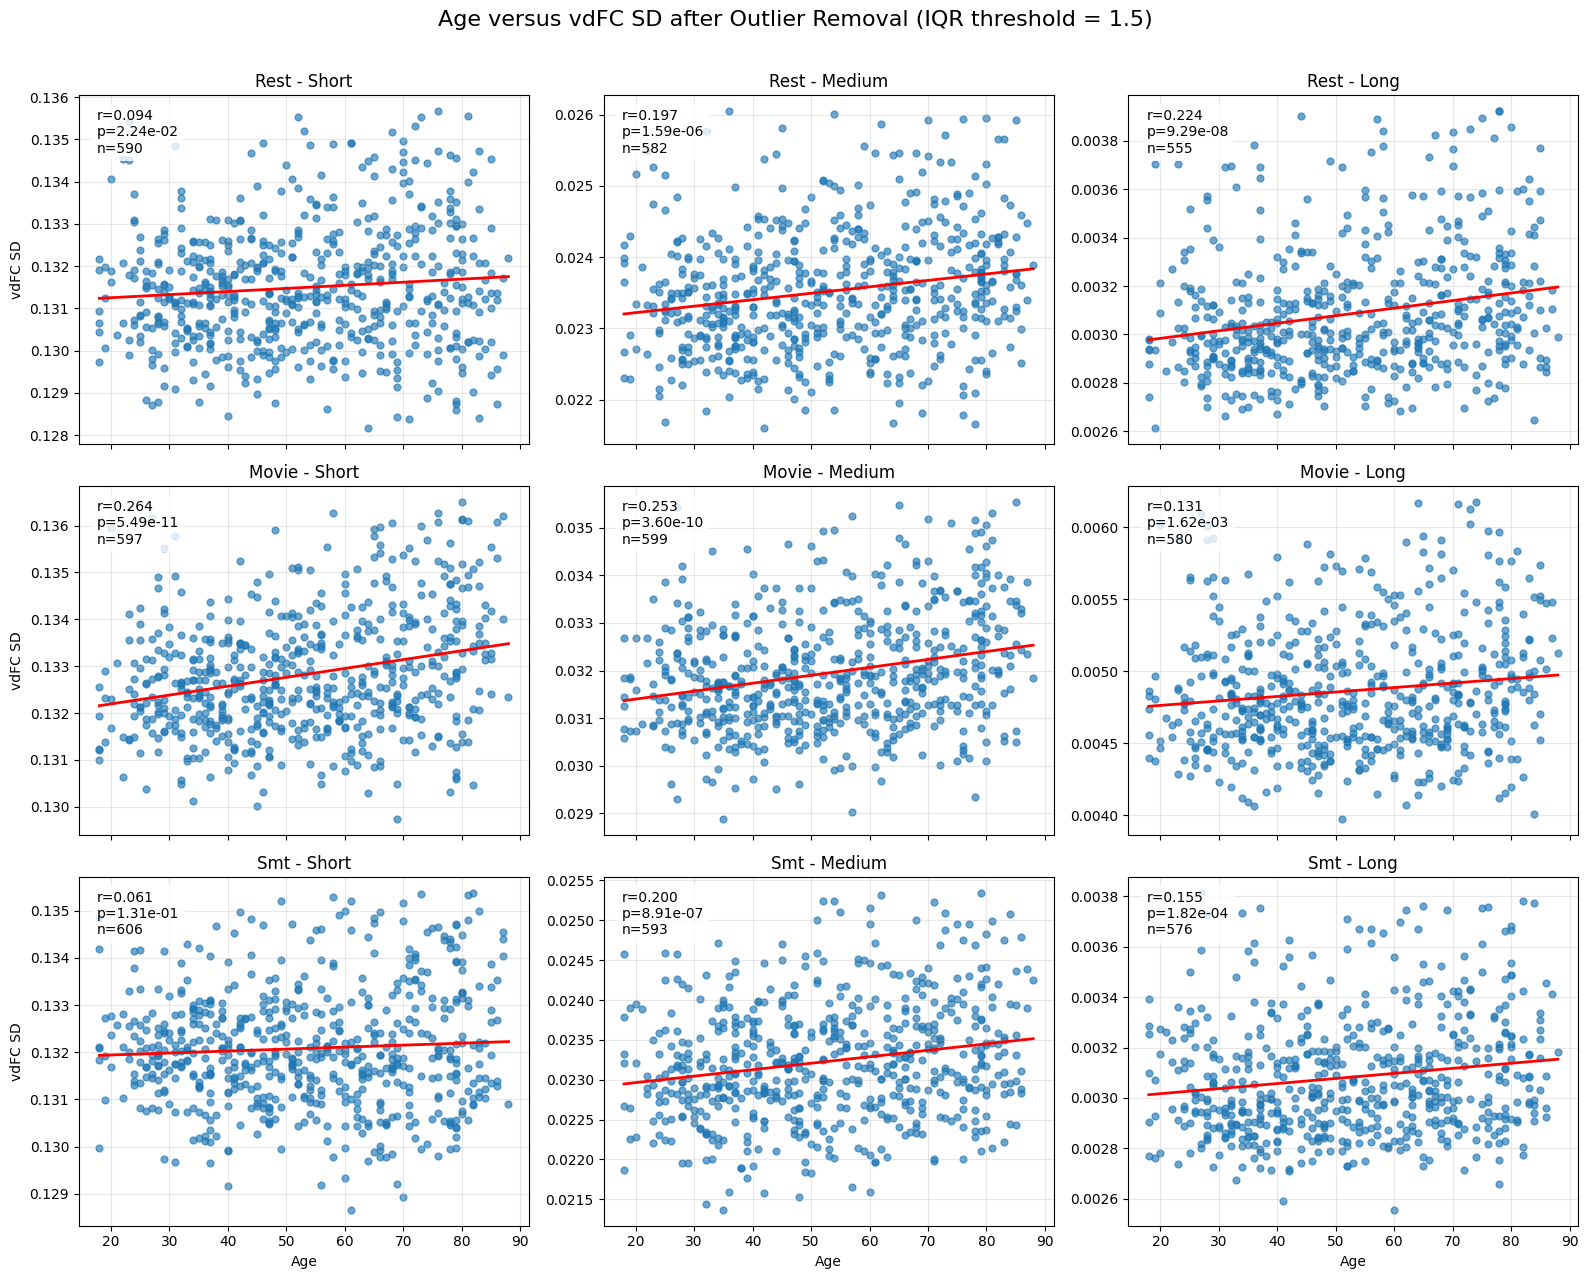

In [14]:
# Plot age versus a selected vdFC metric for every task and window
from scipy.stats import pearsonr

# Choose the vdFC metric to plot.
VDFC_METRIC = "vdfc_sd"  # Options: vdfc_median, vdfc_mean, vdfc_sd
VALID_METRICS = {"vdfc_median", "vdfc_mean", "vdfc_sd"}
if VDFC_METRIC not in VALID_METRICS:
    raise ValueError(f"VDFC_METRIC must be one of: {sorted(VALID_METRICS)}")

# User-adjustable outlier threshold:
# 1.5 is the standard Tukey IQR rule; set to None to disable outlier removal.
OUTLIER_IQR_MULTIPLIER = 1.5

# Adjust these names only if the CSV uses different labels.
TASK_ORDER = ["rest", "movie", "smt"]
WINDOW_ORDER = ["Short", "Medium", "Long"]

# Normalize column names and categorical values for reliable matching.
plot_data = vdfc_values.copy()
plot_data.columns = plot_data.columns.str.strip().str.lower()
required_columns = {"condition", "window", "age", VDFC_METRIC}
missing_columns = required_columns.difference(plot_data.columns)
if missing_columns:
    raise KeyError(f"CSV is missing required columns: {sorted(missing_columns)}")

plot_data["condition"] = plot_data["condition"].astype(str).str.strip().str.lower()
plot_data["window"] = plot_data["window"].astype(str).str.strip().str.title()
plot_data["age"] = pd.to_numeric(plot_data["age"], errors="coerce")
plot_data["plot_metric"] = pd.to_numeric(plot_data[VDFC_METRIC], errors="coerce")

metric_labels = {
    "vdfc_median": "Median vdFC",
    "vdfc_mean": "Mean vdFC",
    "vdfc_sd": "vdFC SD",
}
metric_label = metric_labels[VDFC_METRIC]

fig, axes = plt.subplots(
    nrows=len(TASK_ORDER),
    ncols=len(WINDOW_ORDER),
    figsize=(16, 13),
    sharex=True,
)

for row_idx, task in enumerate(TASK_ORDER):
    for col_idx, window in enumerate(WINDOW_ORDER):
        ax = axes[row_idx, col_idx]
        panel = plot_data[
            (plot_data["condition"] == task)
            & (plot_data["window"] == window)
        ][["age", "plot_metric"]].dropna()

        if OUTLIER_IQR_MULTIPLIER is not None and not panel.empty:
            q1 = panel["plot_metric"].quantile(0.25)
            q3 = panel["plot_metric"].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - OUTLIER_IQR_MULTIPLIER * iqr
            upper_bound = q3 + OUTLIER_IQR_MULTIPLIER * iqr
            panel = panel[panel["plot_metric"].between(lower_bound, upper_bound)]

        if len(panel) >= 2:
            x_values = panel["age"].to_numpy()
            y_values = panel["plot_metric"].to_numpy()
            correlation, p_value = pearsonr(x_values, y_values)

            ax.scatter(x_values, y_values, alpha=0.65, s=24)
            slope, intercept = np.polyfit(x_values, y_values, 1)
            x_fit = np.linspace(x_values.min(), x_values.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, color="red", linewidth=2)
            ax.text(
                0.04,
                0.96,
                f"r={correlation:.3f}\np={p_value:.2e}\nn={len(panel)}",
                transform=ax.transAxes,
                va="top",
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
            )
        else:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(f"{task.title()} - {window}")
        ax.grid(True, alpha=0.3)
        if row_idx == len(TASK_ORDER) - 1:
            ax.set_xlabel("Age")
        if col_idx == 0:
            ax.set_ylabel(metric_label)

threshold_label = "none" if OUTLIER_IQR_MULTIPLIER is None else str(OUTLIER_IQR_MULTIPLIER)
fig.suptitle(
    f"Age versus {metric_label} after Outlier Removal (IQR threshold = {threshold_label})",
    fontsize=16,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()